### 1. 환경변수 로드

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

### 2. State 정의
- `messages`에 `add_messages` reducer를 붙여 노드가 반환한 메시지를 덮어쓰지 않고 누적함

In [2]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

### 3. 노드(챗봇) 정의

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

def chatbot(state: State):   # 누적된 messages를 그대로 LLM에 전달, 응답을 리스트로 반환 → add_messages가 누적
    return {"messages": [llm.invoke(state["messages"])]}

### 4. 그래프 구성 및 컴파일
- `START → chatbot → END` 단일 노드 그래프

In [4]:
graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)

In [5]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)
graph = graph_builder.compile()   # 엣지 연결을 마친 뒤 compile → 실행 가능한 그래프 생성

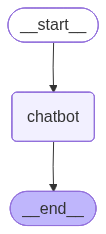

In [6]:
graph

### 5. 실행 (stream)
- `stream`은 노드 실행 단위로 이벤트를 방출 → 각 노드가 갱신한 state를 순차적으로 확인 가능

In [7]:
question = "서울의 대표 종합병원 10곳 소개해주세요"

for event in graph.stream({"messages": [("user", question)]}):
    for value in event.values():
        print("Assistant:", value["messages"][-1].content)

Assistant: 서울에는 많은 종합병원이 있으며, 그 중에서도 특히 유명하고 신뢰받는 병원들을 소개하겠습니다.

1. **서울대학교병원**: 서울대학교 의과대학 부속 병원으로, 국내 최고의 의료기관 중 하나입니다. 다양한 전문 진료과와 연구 시설을 갖추고 있습니다.

2. **삼성서울병원**: 삼성그룹이 운영하는 병원으로, 최신 의료 기술과 시설을 갖추고 있으며, 다양한 전문 진료를 제공합니다.

3. **세브란스병원**: 연세대학교 의과대학 부속 병원으로, 오랜 역사와 전통을 가지고 있으며, 다양한 전문 분야에서 우수한 진료를 제공합니다.

4. **아산병원**: 아산재단이 운영하는 병원으로, 첨단 의료 기술과 연구를 바탕으로 한 진료를 제공합니다. 특히 심장 및 암 치료에 강점을 가지고 있습니다.

5. **한양대학교병원**: 한양대학교 의과대학 부속 병원으로, 다양한 전문 진료과와 연구 시설을 갖추고 있습니다.

6. **고려대학교안암병원**: 고려대학교 의과대학 부속 병원으로, 다양한 진료과와 연구를 통해 환자에게 최상의 의료 서비스를 제공합니다.

7. **중앙대학교병원**: 중앙대학교 의과대학 부속 병원으로, 다양한 전문 진료와 연구를 통해 환자에게 양질의 의료 서비스를 제공합니다.

8. **국립중앙의료원**: 정부가 운영하는 병원으로, 공공의료를 담당하며, 다양한 전문 진료와 연구를 진행하고 있습니다.

9. **서울특별시보라매병원**: 서울시가 운영하는 병원으로, 다양한 진료과와 함께 지역 주민들에게 양질의 의료 서비스를 제공합니다.

10. **이대목동병원**: 이화여자대학교 의과대학 부속 병원으로, 여성 및 소아 전문 진료에 강점을 가지고 있으며, 다양한 진료 서비스를 제공합니다.

이 외에도 서울에는 많은 우수한 종합병원이 있으며, 각 병원마다 특화된 분야와 전문성이 있습니다. 필요에 따라 적절한 병원을 선택하는 것이 중요합니다.
